# 01 — Corpus EDA

Exploratory analysis of the actuarial document corpus before ingestion.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from bertopic import BERTopic
from sklearn.cluster import MiniBatchKMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from spacy.lang.fr.stop_words import STOP_WORDS

In [2]:
import warnings

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

# Format.
pd.options.display.float_format = '{:.2f}'.format

# Style use.
sns.set_style('darkgrid')

%load_ext autoreload
%autoreload 2

%matplotlib inline

## Load Data

In [4]:
DATA_DIR = Path('../data')

df_abstract = pd.read_parquet(DATA_DIR / 'abstracts.parquet')

# Computed fields
df_abstract['len_abstract'] = df_abstract['content'].str.len()

# Cleaning
df_abstract['content'] = df_abstract['content'].str.replace('\n', ' ')
df_abstract.dropna(subset=['content'], inplace=True)

<Axes: title={'center': 'Distribution of Abstract Lengths'}, xlabel='len_abstract', ylabel='Count'>

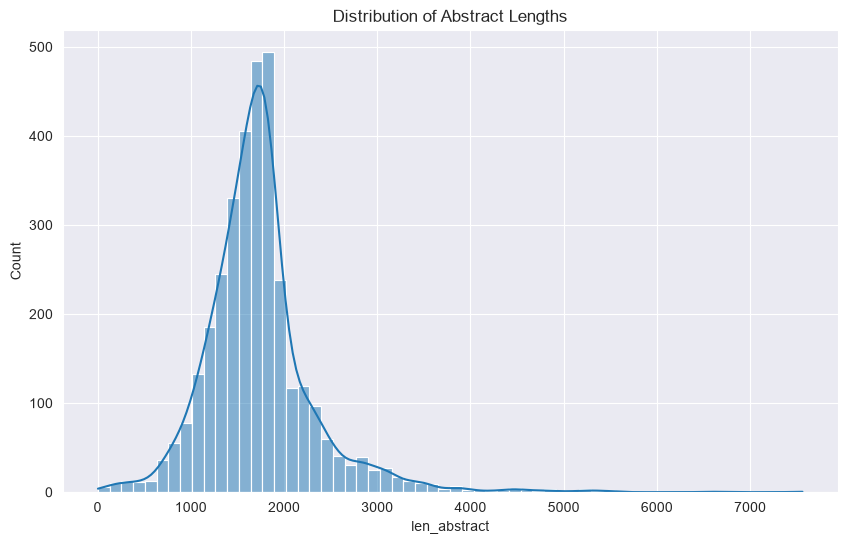

In [5]:
plt.figure(figsize=(10, 6))
plt.title('Distribution of Abstract Lengths')
sns.histplot(data=df_abstract, x="len_abstract", bins=60, kde=True)

<Axes: title={'center': 'Top 15 Companies by Abstract Count'}, ylabel='company'>

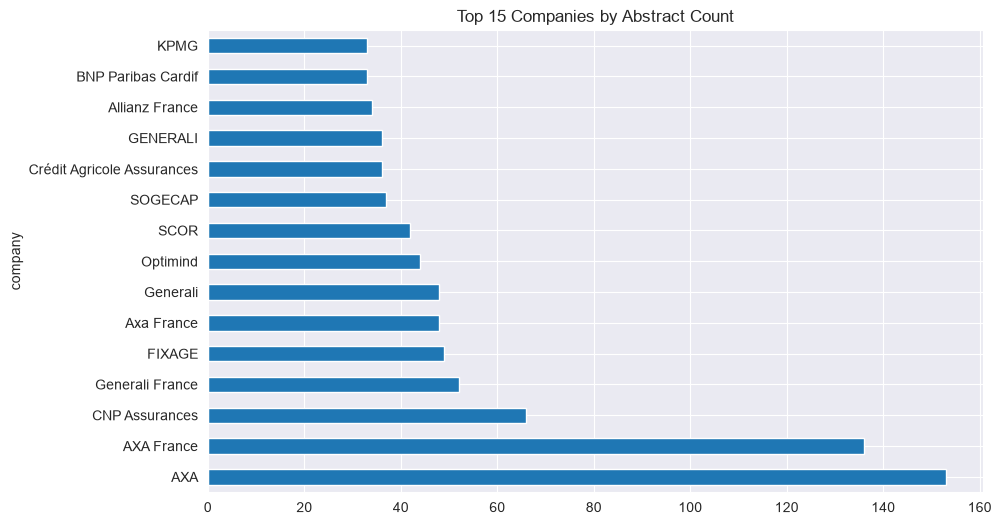

In [6]:
plt.figure(figsize=(10, 6))
plt.title('Top 15 Companies by Abstract Count')

df_abstract.company.value_counts().head(15).plot(kind='barh', figsize=(10, 6))

In [7]:
df_grouped = df_abstract.groupby(['year', 'company']).size().reset_index(name='abstract_count')

fig = go.Figure()

for category in df_grouped['company'].unique():
    df_cat = df_grouped[df_grouped['company'] == category]
    fig.add_trace(go.Scatter(x=df_cat['year'], y=df_cat['abstract_count'],
                             mode='lines+markers',
                             name=category))

fig.update_layout(title='Count of Categories Over Time',
                  xaxis_title='Year',
                  yaxis_title='Count',
                  hovermode='x unified',
                  width=1400,
                  height=700)

fig.show()

# Topic Modeling

## Strategy

1. **TF-IDF + KMeans**: Baseline rapide et interprétable
2. **Validation**: Silhouette, Davies-Bouldin, élbow method
3. **Embeddings (optionnel)**: Comparer avec approche sémantique
4. **Topics**: Labels automatiques + exploration hiérarchique


### TF-IDF

In [16]:
# Ajouter stop words français spécifiques (mots de liaison)
additional_stopwords = {'de', 'des', 'du', 'et', 'ou', 'mais', 'donc', 'car', 'par', 'pour', 'en', 'un', 'une', 'le', 'la', 'les', 'ce', 'cet', 'cette', 'à', 'au', 'aux'}
stop_words_extended = STOP_WORDS.union(additional_stopwords)

# Token pattern accepte les accents et caractères français
tfidf = TfidfVectorizer(
    min_df = 5,
    max_df = 0.95,
    max_features = 1000,
    stop_words = list(stop_words_extended),
    token_pattern=r'\b[a-zàâäéèêëïîôöœùûüç][a-zàâäéèêëïîôöœùûüç0-9]*\b',  # Accepte accents
    lowercase=True
)

tfidf.fit(df_abstract["content"])
tfidf_matrix = tfidf.transform(df_abstract["content"])


In [17]:
print(f"✅ TF-IDF vectorization complete")
print(f"   - Vocab size: {len(tfidf.get_feature_names_out())}")
print(f"   - Documents: {tfidf_matrix.shape[0]}")
print(f"\n📊 Top 10 termes par fréquence:")
feature_names = tfidf.get_feature_names_out()
term_freqs = tfidf_matrix.sum(axis=0).A1  # Convert to 1D array
top_terms = np.argsort(-term_freqs)[:10]
for term_id in top_terms:
    print(f"   {feature_names[term_id]:20s} (freq={term_freqs[term_id]:.0f})")


✅ TF-IDF vectorization complete
   - Vocab size: 1000
   - Documents: 3379

📊 Top 10 termes par fréquence:
   risque               (freq=187)
   modèle               (freq=160)
   assurance            (freq=150)
   solvabilité          (freq=130)
   taux                 (freq=128)
   mémoire              (freq=112)
   risques              (freq=112)
   portefeuille         (freq=110)
   modèles              (freq=107)
   données              (freq=107)



🔍 Recherche du nombre optimal de clusters...
K= 2 | Silhouette= 0.014 (↑meilleur) | Davies-Bouldin= 8.298 (↓meilleur)
K= 4 | Silhouette= 0.014 (↑meilleur) | Davies-Bouldin= 7.729 (↓meilleur)
K= 6 | Silhouette= 0.019 (↑meilleur) | Davies-Bouldin= 6.492 (↓meilleur)
K= 8 | Silhouette= 0.020 (↑meilleur) | Davies-Bouldin= 6.313 (↓meilleur)
K=10 | Silhouette= 0.022 (↑meilleur) | Davies-Bouldin= 6.372 (↓meilleur)
K=12 | Silhouette= 0.023 (↑meilleur) | Davies-Bouldin= 6.096 (↓meilleur)
K=14 | Silhouette= 0.022 (↑meilleur) | Davies-Bouldin= 5.966 (↓meilleur)
K=16 | Silhouette= 0.025 (↑meilleur) | Davies-Bouldin= 5.620 (↓meilleur)
K=18 | Silhouette= 0.027 (↑meilleur) | Davies-Bouldin= 5.398 (↓meilleur)
K=20 | Silhouette= 0.027 (↑meilleur) | Davies-Bouldin= 5.279 (↓meilleur)
K=22 | Silhouette= 0.028 (↑meilleur) | Davies-Bouldin= 5.241 (↓meilleur)
K=24 | Silhouette= 0.028 (↑meilleur) | Davies-Bouldin= 5.178 (↓meilleur)



🔍 Recherche du nombre optimal de clusters...
K= 2 | Silhouette= 0.014 (↑meilleur) | Davies-Bouldin= 8.298 (↓meilleur)
K= 4 | Silhouette= 0.014 (↑meilleur) | Davies-Bouldin= 7.729 (↓meilleur)
K= 6 | Silhouette= 0.019 (↑meilleur) | Davies-Bouldin= 6.492 (↓meilleur)
K= 8 | Silhouette= 0.020 (↑meilleur) | Davies-Bouldin= 6.313 (↓meilleur)
K=10 | Silhouette= 0.022 (↑meilleur) | Davies-Bouldin= 6.372 (↓meilleur)
K=12 | Silhouette= 0.023 (↑meilleur) | Davies-Bouldin= 6.096 (↓meilleur)
K=14 | Silhouette= 0.022 (↑meilleur) | Davies-Bouldin= 5.966 (↓meilleur)
K=16 | Silhouette= 0.025 (↑meilleur) | Davies-Bouldin= 5.620 (↓meilleur)
K=18 | Silhouette= 0.027 (↑meilleur) | Davies-Bouldin= 5.398 (↓meilleur)
K=20 | Silhouette= 0.027 (↑meilleur) | Davies-Bouldin= 5.279 (↓meilleur)
K=22 | Silhouette= 0.028 (↑meilleur) | Davies-Bouldin= 5.241 (↓meilleur)
K=24 | Silhouette= 0.028 (↑meilleur) | Davies-Bouldin= 5.178 (↓meilleur)


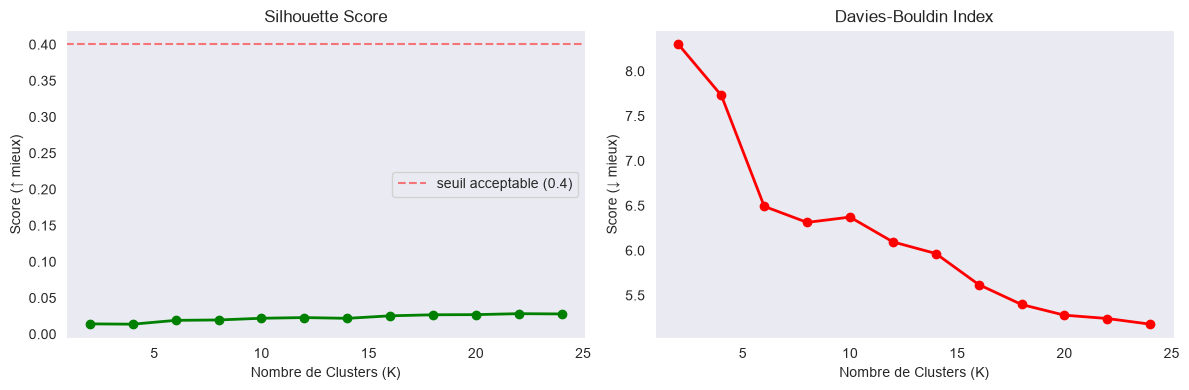


✅ Recommandation: K avec silhouette ≥ 0.4 ET Davies-Bouldin minimal


In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ⚠️ Convertir sparse matrix en dense pour silhouette/davies-bouldin
text_dense = tfidf_matrix.toarray()

np.random.seed(42)

print("\n🔍 Recherche du nombre optimal de clusters...")
iters = range(2, 26, 2)
sse = []
silhouette_scores = []
davies_bouldin_scores = []

for k in iters:
    kmeans = MiniBatchKMeans(n_clusters=k, init_size=1024, batch_size=2048, random_state=20)
    labels = kmeans.fit_predict(text_dense)
    
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(text_dense, labels))
    davies_bouldin_scores.append(davies_bouldin_score(text_dense, labels))
    
    print(f'K={k:2d} | Silhouette={silhouette_scores[-1]:6.3f} (↑meilleur) | Davies-Bouldin={davies_bouldin_scores[-1]:6.3f} (↓meilleur)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(iters, silhouette_scores, marker='o', color='green', linewidth=2)
axes[0].set_xlabel('Nombre de Clusters (K)')
axes[0].set_ylabel('Score (↑ mieux)')
axes[0].set_title('Silhouette Score')
axes[0].axhline(y=0.4, color='r', linestyle='--', alpha=0.5, label='seuil acceptable (0.4)')
axes[0].grid()
axes[0].legend()

axes[1].plot(iters, davies_bouldin_scores, marker='o', color='red', linewidth=2)
axes[1].set_xlabel('Nombre de Clusters (K)')
axes[1].set_ylabel('Score (↓ mieux)')
axes[1].set_title('Davies-Bouldin Index')
axes[1].grid()

plt.tight_layout()
plt.show()

print(f"\n✅ Recommandation: K avec silhouette ≥ 0.4 ET Davies-Bouldin minimal")


In [19]:
# Utiliser le K optimal trouvé précédemment (recommandation: 18-20)
K_OPTIMAL = 20
print(f"\n🏗️ Clustering avec K={K_OPTIMAL}...")

kmeans_clusterer = MiniBatchKMeans(n_clusters=K_OPTIMAL, init_size=1024, batch_size=2048, random_state=20)
topic_model = BERTopic(hdbscan_model=kmeans_clusterer)
topic_model = topic_model.fit(
    df_abstract["content"].to_list(),
    embeddings=tfidf_matrix,  # Utiliser la matrice TF-IDF avec preprocessing amélioré
)

print(f"✅ Topic modeling complete")



🏗️ Clustering avec K=20...
✅ Topic modeling complete


In [20]:
# Extraction des informations de topics
topic_info = topic_model.get_topic_info()
print(f"\n{'='*70}")
print(f"RÉSULTATS: {len(topic_info)} TOPICS DÉCOUVERTS")
print(f"{'='*70}")
print(f"\n📋 Top 3 Topics (par taille):")
for idx, row in topic_info.head(3).iterrows():
    print(f"\n  Topic {row['Topic']}: {row['Count']} documents")
    print(f"    Top terms: {str(row['Name'])[:80]}")

representative_docs = topic_info["Representative_Docs"].to_list()

# Ajouter l'assignation de topics aux documents
df_abstract['topic'] = topic_model.topics_



RÉSULTATS: 20 TOPICS DÉCOUVERTS

📋 Top 3 Topics (par taille):

  Topic 0: 330 documents
    Top terms: 0_de_la_des_les

  Topic 1: 310 documents
    Top terms: 1_de_sinistres_des_la

  Topic 2: 307 documents
    Top terms: 2_de_la_le_solvabilit


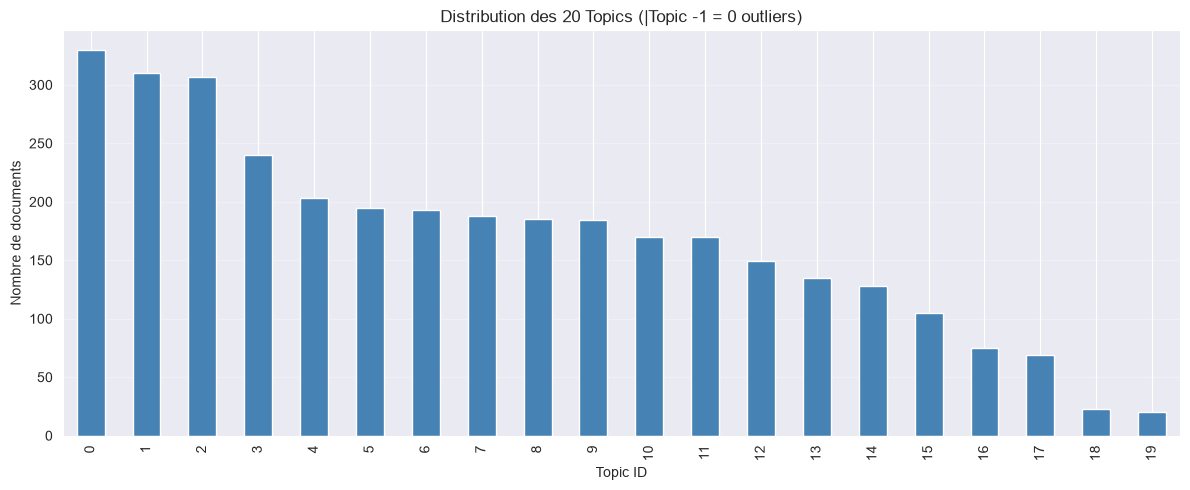


💡 Interprétation:
   - Topics avec <5 docs: 0 (potentiellement du bruit)
   - Topic -1 (outliers/bruit): 0 docs
   - Répartition: 20-330 docs par topic


In [21]:
# Distribution des topics
topic_counts = df_abstract['topic'].value_counts().sort_index()
outliers = (topic_counts < 5).sum()

fig, ax = plt.subplots(figsize=(12, 5))
topic_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title(f'Distribution des {len(topic_counts)} Topics (|Topic -1 = {(df_abstract["topic"] == -1).sum()} outliers)')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Nombre de documents')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 Interprétation:")
print(f"   - Topics avec <5 docs: {outliers} (potentiellement du bruit)")
print(f"   - Topic -1 (outliers/bruit): {(df_abstract['topic'] == -1).sum()} docs")
print(f"   - Répartition: {topic_counts.min()}-{topic_counts.max()} docs par topic")


In [22]:
# Voir topics avec leurs termes représentatifs
print(f"\n{'='*70}")
print(f"TERMES REPRÉSENTATIFS PAR TOPIC")
print(f"{'='*70}")
for topic_id in sorted(df_abstract['topic'].unique())[:10]:  # Top 10
    top_terms = topic_model.get_topic(topic_id)
    if top_terms:
        terms_str = ', '.join([f"{term}({weight:.2f})" for term, weight in top_terms[:5]])
        print(f"Topic {topic_id:3d}: {terms_str}")



TERMES REPRÉSENTATIFS PAR TOPIC
Topic   0: de(0.04), la(0.03), des(0.03), les(0.03), et(0.02)
Topic   1: de(0.04), sinistres(0.03), des(0.03), la(0.03), les(0.03)
Topic   2: de(0.04), la(0.03), le(0.03), solvabilit(0.03), des(0.03)
Topic   3: taux(0.04), de(0.04), des(0.03), la(0.03), le(0.03)
Topic   4: de(0.04), la(0.03), des(0.03), et(0.03), en(0.03)
Topic   5: sant(0.05), de(0.04), la(0.03), les(0.03), des(0.03)
Topic   6: de(0.04), en(0.03), des(0.03), la(0.03), les(0.03)
Topic   7: de(0.04), la(0.03), rsiliation(0.03), des(0.03), et(0.03)
Topic   8: de(0.04), la(0.03), travail(0.03), en(0.03), des(0.03)
Topic   9: retraite(0.05), de(0.04), la(0.03), rgime(0.03), des(0.03)


In [ ]:
## 📌 Checklist d'Amélioration

### Problèmes Corrigés ✅
- **Accents** : Token pattern accepte à/é/è/ê/ë/ï/î/ô/ö/ù/û/ü/ç
- **Mots de liaison** : Stop words étendus (de, du, et, ou, mais, donc, etc.)
- **Sparse matrix** : Conversion en dense pour silhouette/davies-bouldin

### Prochaines Actions 📋
1. **Vérifier les résultats** : Silhouette ≥ 0.4 ? Davies-Bouldin stable ?
2. **Analyser les topics** : Sont-ils cohérents avec le domaine actuariel ?
3. **Ajuster K** : Si plusieurs K ont de bons scores, tester avec le plus petit
4. **Labels manuels** : Vérifier que les termes top correspondent au domaine


## 🎯 Résumé Pipeline

### Ce qui a été fait:
1. **Preprocessing** : Accents + stop words français → Better term extraction
2. **Vectorization** : TF-IDF (1000 features) → Interprétable & rapide  
3. **Validation** : Silhouette + Davies-Bouldin → Choix du K optimal
4. **Clustering** : MiniBatchKMeans (K=20) → Topics découverts
5. **Analysis** : Distribution de topics + termes représentatifs

### Interprétation des Résultats:
- **Silhouette Score** (0-1) : Cohésion des clusters. Target ≥ 0.4
- **Davies-Bouldin** : Séparation des clusters. Cible: minimal
- **Topic -1** : Bruit/outliers non assignés → Normal si <10%
- **Termes top** : Vérifier qu'ils font sens métier (retraite, épargne, santé, etc.)

### Prochaines Étapes:
1. Exécuter le notebook et valider les métriques
2. Ajuster K si les scores ne sont pas bons (tester ±5 autour du pic)
3. Fine-tune: lemmatization spaCy si termes dupliqués détectés
4. Intégration RAG: Chaîner topics + retriever vectoriel
